# Лаб.2 Ульченко 24ВВИм1

Другой популярной процедурой адаптивной гистограммной обработки изображения является *эквализация* изображения. Эквализация также отображает реальный яркостный диапазон данного изображения (от минимального до максимального значения интенсивности) на диапазон [0, 255]. При этом обеспечивается "выравнивание" числа пикселов изображения, имеющих различные значения яркости. Математическая форма данного преобразования имеет вид
$$
{\rm LUT}[i] = 255 \cdot  \frac{\sum\limits_{j=1}^i \textrm{Hist}[j]} {\sum\limits_{j=1}^{255} \textrm{Hist}[j]},
$$
В тех случаях, когда в диапазоне [Imin,Imax] более или менее равномерно присутствуют все градации, визуальный эффект от эквализации трудно отличить от эффекта нормализации. Однако в случае, когда значительная часть градаций яркости отсутствует, эквализация позволяет более равномерно использовать диапазон [0,255] для более контрастного отображения присутствующих на изображении градаций. Визуально это выглядит как "проявление" большего количества ранее не заметных на изображении деталей и контуров.

## **Задание: реализуйте данный вид эквализации самостоятельно**

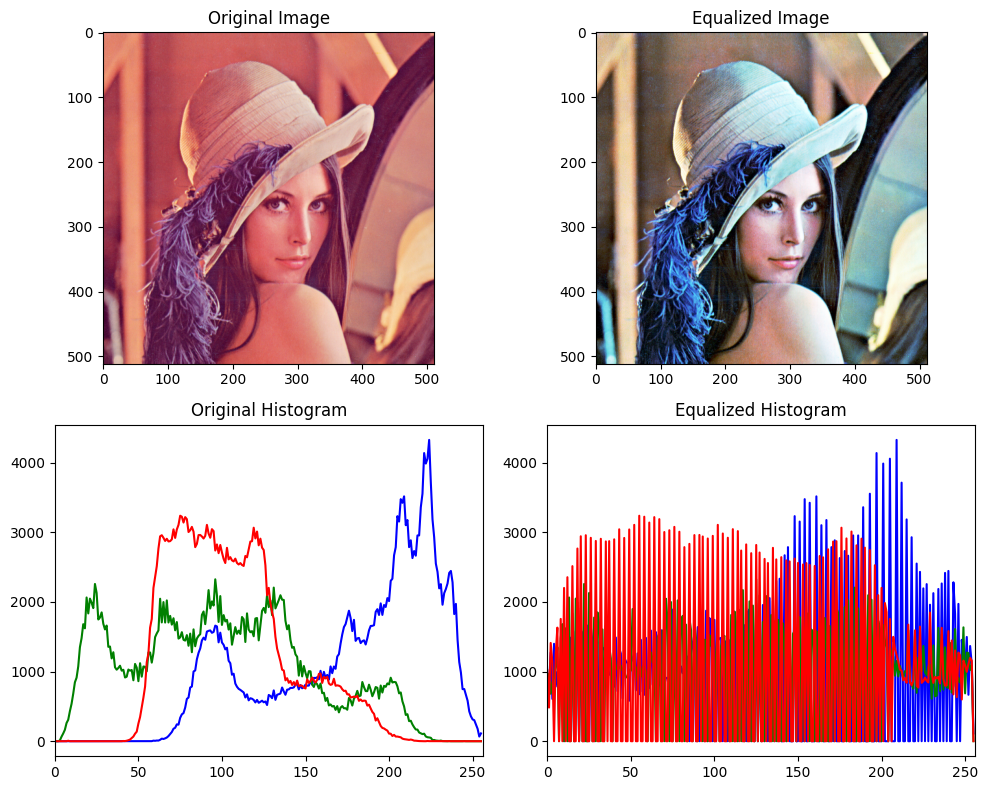

In [5]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def plot_rgb_hist(image):
    histSize = [256]
    range = [0, 256]
    for i, col in enumerate(['b', 'g', 'r']):
        hist = cv.calcHist([image], [i], None, histSize, range)
        plt.plot(hist, color=col)
        plt.xlim(range)

def equalize_channel(channel):
    hist = cv.calcHist([channel], [0], None, [256], [0, 256]).ravel()
    cdf = hist.cumsum()
    cdf_normalized = (cdf * 255 / cdf[-1]).astype('uint8')
    return cv.LUT(channel, cdf_normalized)

rgb_image = cv.cvtColor(cv.imread('lenna.png'), cv.COLOR_BGR2RGB)

rgb_equalized = np.zeros_like(rgb_image)
for i in range(3):
    rgb_equalized[:, :, i] = equalize_channel(rgb_image[:, :, i])

gs = plt.GridSpec(2, 2)
plt.figure(figsize=(10, 8))

plt.subplot(gs[0])
plt.imshow(rgb_image)
plt.title('Original Image')

plt.subplot(gs[1])
plt.imshow(rgb_equalized)
plt.title('Equalized Image')

plt.subplot(gs[2])
plot_rgb_hist(rgb_image)
plt.title('Original Histogram')

plt.subplot(gs[3])
plot_rgb_hist(rgb_equalized)
plt.title('Equalized Histogram')

plt.tight_layout()
plt.show()